# Supersonic Panel

CLT stress and failure analysis for a composite upper-wing skin panel at a supersonic cruise condition, following the same steps as `demo_supersonic_panel.py`.

- Ackeret linearised supersonic theory for aerodynamic running loads
- CLT ABD matrix and midplane strains/curvatures
- Tsai-Wu reserve factor per ply
- Stacking sequence trade: sweep off-axis angle to find the best margin

**Mission context:** Mach 1.6 cruise at 15,000 m, upper skin at 40% semi-span, IM7/8552 `[±45/0/90]_s`.

In [1]:
import sys, os
from pathlib import Path

# Resolve repo root regardless of where Jupyter was launched from
_nb_dir = Path(os.path.abspath("")).resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
sys.path.insert(0, str(_repo_root / "src"))

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from composite_panel import Ply, Laminate, IM7_8552
from composite_panel import check_laminate
from composite_panel import supersonic_panel_loads

---
## 1. Mission and Panel Geometry

These fixed parameters define the design point. Changing `MACH` or `ALT_M` automatically recomputes all downstream loads.

In [2]:
MACH        = 1.6       # Free-stream Mach number (Ackeret theory valid ~1.1-4)
ALT_M       = 15_000    # Cruise altitude [m]
ALPHA_DEG   = 3.0       # Angle of attack [deg]

PANEL_CHORD = 0.80      # Chordwise panel dimension [m] (stringer-to-stringer)
PANEL_SPAN  = 0.50      # Spanwise panel dimension [m] (rib-to-rib)

N_LOAD      = 2.5       # Ultimate load factor (limit × 1.5)

print(f'Mach {MACH} @ {ALT_M/1e3:.0f} km  |  alpha = {ALPHA_DEG} deg')
print(f'Panel: {PANEL_CHORD*100:.0f} cm chord x {PANEL_SPAN*100:.0f} cm span  |  n = {N_LOAD} g')

Mach 1.6 @ 15 km  |  alpha = 3.0 deg
Panel: 80 cm chord x 50 cm span  |  n = 2.5 g


---
## 2. Material and Laminate

**IM7/8552** is a high-performance aerospace carbon-epoxy system. Key unidirectional ply properties:

| Property | Value | Meaning |
|----------|-------|---------|
| E1 | 171.4 GPa | Fibre-direction modulus |
| E2 | 9.08 GPa | Transverse modulus |
| G12 | 5.29 GPa | In-plane shear modulus |
| nu12 | 0.32 | Major Poisson ratio |
| F1t | 2326 MPa | Longitudinal tensile strength |
| F1c | 1200 MPa | Longitudinal compressive strength |
| F2t | 62 MPa | Transverse tensile strength |
| F2c | 200 MPa | Transverse compressive strength |
| F6 | 110 MPa | In-plane shear strength |

The chosen stacking sequence is **quasi-isotropic** `[±45/0/90]_s`. "Quasi-isotropic" means the A-matrix (in-plane stiffness) is isotropic — every in-plane direction has the same extensional stiffness. This is a common first-design choice when the load path is not yet well established.

The `_s` denotes a **symmetric** laminate: the half-stack is mirrored about the mid-plane, which forces `B = 0` (no bending-stretching coupling). This is a standard design rule.

In [3]:
PLY_T = 0.125e-3    # Standard IM7 prepreg cured ply thickness [m] = 0.125 mm
mat   = IM7_8552()

# [+-45 / 0 / 90]_s  full 8-ply symmetric stack
# Bottom half (z < 0): [-45, 0, 45, 90]
# Mirror (z > 0):      [90, 45, 0, -45]
angles = [-45, 0, 45, 90,
           90, 45, 0, -45]

plies = [Ply(mat, PLY_T, a) for a in angles]
lam   = Laminate(plies)

print(mat)
print()
print(lam.summary())

PlyMaterial(E1=171400000000.0, E2=9080000000.0, G12=5290000000.0, nu12=0.32, F1t=2326000000.0, F1c=1200000000.0, F2t=62000000.0, F2c=200000000.0, F12=90000000.0, name='IM7/8552')

Laminate  –  8 plies  |  h = 1.000 mm
  Stacking: [-45/0/45/90/90/45/0/-45]

  A matrix [MN/m]:
        71.425      22.229       0.000
        22.229      71.425       0.000
         0.000       0.000      24.598

  D matrix [N·m]:
         7.261       2.456      -1.594
         2.456       3.436      -1.594
        -1.594      -1.594       2.653


---
## 3. Aerodynamic Loads — Ackeret Linearised Supersonic Theory

**Ackeret (1925)** derived the pressure coefficient for a flat surface in 2-D supersonic flow using linearised small-disturbance theory:

$$\Delta C_p = \frac{4\alpha}{\sqrt{M^2 - 1}}$$

where alpha is in radians and the denominator is the Prandtl-Glauert supersonic compressibility factor.

The net pressure on the panel drives the structural **running loads** (force per unit width, N/m):

| Load | Formula | Physical meaning |
|------|---------|------------------|
| Nyy | -Δp × chord / 2 | Chordwise compression (upper skin pushed inward) |
| Nxx | Nyy × 0.6 | Spanwise load (beam-flange bending model) |
| Nxy | \|Nxx\| × 0.25 | Torsion → shear flow |
| Mxx | Δp × chord² / 8 | Panel bending (simply-supported boundary conditions) |

The ISA atmosphere model gives density and speed of sound at `ALT_M`.

In [4]:
loads = supersonic_panel_loads(
    mach        = MACH,
    altitude_m  = ALT_M,
    alpha_deg   = ALPHA_DEG,
    panel_chord = PANEL_CHORD,
    panel_span  = PANEL_SPAN,
    n_load      = N_LOAD,
)

print(loads)
print()
print(f'Nxx = {loads.Nxx/1e3:+.1f} kN/m  (spanwise)')
print(f'Nyy = {loads.Nyy/1e3:+.1f} kN/m  (chordwise)  <- usually governs on upper skin')
print(f'Nxy = {loads.Nxy/1e3:+.1f} kN/m  (shear)')
print(f'Mxx = {loads.Mxx:+.2f} N·m/m  (bending moment)')

PanelLoads  Nxx=-2.2 kN/m  Nyy=-3.6 kN/m  Nxy=+0.5 kN/m

Nxx = -2.2 kN/m  (spanwise)
Nyy = -3.6 kN/m  (chordwise)  <- usually governs on upper skin
Nxy = +0.5 kN/m  (shear)
Mxx = +723.85 N·m/m  (bending moment)


---
## 4. CLT Response — Midplane Strains and Curvatures

Classical Laminate Theory solves the constitutive relation:

$$\begin{bmatrix} N \\ M \end{bmatrix} = \begin{bmatrix} A & B \\ B & D \end{bmatrix} \begin{bmatrix} \varepsilon_0 \\ \kappa \end{bmatrix}$$

For a **symmetric** laminate `B = 0`, so the problem decouples cleanly:

- Membrane: `{N} = [A]{eps0}` → solve for midplane strains `eps0 = A_inv @ N`
- Bending: `{M} = [D]{kappa}` → solve for curvatures `kappa = D_inv @ M`

Once `eps0` and `kappa` are known, the strain at the mid-plane of each ply at height z is:

$$\varepsilon(z) = \varepsilon_0 + z \cdot \kappa$$

Multiplying by the ply's transformed stiffness `Q_bar` gives stresses in the global (x-y) frame, which are then rotated into the ply's material (1-2) frame for failure checking.

In [5]:
res = lam.response(N=loads.N, M=loads.M)

print('Midplane strains eps0 [microstrain]:')
labels_e = ['exx', 'eyy', 'gxy']
for lbl, e in zip(labels_e, res['eps0']):
    print(f'  {lbl} = {e*1e6:+.1f} ue')

print()
print('Curvatures kappa [1/m]:')
labels_k = ['kxx', 'kyy', 'kxy']
for lbl, k in zip(labels_k, res['kappa']):
    print(f'  {lbl} = {k:+.5f} 1/m')

Midplane strains eps0 [microstrain]:
  exx = -16.2 ue
  eyy = -45.6 ue
  gxy = +22.1 ue

Curvatures kappa [1/m]:
  kxx = +134.09381 1/m
  kyy = -81.05979 1/m
  kxy = +31.85836 1/m


---
## 5. Failure Analysis — Tsai-Wu Criterion

The **Tsai-Wu** criterion (Tsai & Wu 1971) is a tensor polynomial interaction criterion. For plane stress:

$$f(\sigma) = F_1\sigma_1 + F_2\sigma_2 + F_{11}\sigma_1^2 + F_{22}\sigma_2^2 + F_{66}\tau_{12}^2 + 2F_{12}\sigma_1\sigma_2 = 1$$

The **reserve factor** RF is the load multiplier that would cause first-ply failure:

$$f(RF \cdot \sigma) = 1 \quad \Rightarrow \quad a \cdot RF^2 + b \cdot RF - 1 = 0$$

$$RF = \frac{-b + \sqrt{b^2 + 4a}}{2a}$$

This smooth quadratic form is fully differentiable (important for gradient-based optimisation).

Design thresholds:
- `RF < 1.0` — ply has already failed
- `1.0 <= RF < 1.5` — structurally intact but below design target
- `RF >= 1.5` — meets the required margin of safety

In [6]:
results = check_laminate(res, plies, criterion='tsai_wu', verbose=True)

rfs = [r.rf for r in results]
print(f'\nGoverning (minimum) RF = {min(rfs):.3f}  (ply {rfs.index(min(rfs))} @ {angles[rfs.index(min(rfs))]}°)')


Failure Analysis  –  tsai_wu
-----------------------------------------------------------------
  [FAIL] Ply  0  θ=-45.0°  RF=0.2026  (1:1.396  2:1.091  12:0.181  comb:0.2026)
  [FAIL] Ply  1  θ=  0.0°  RF=0.1364  (1:0.168  2:0.572  12:1.713  comb:0.1364)
  [FAIL] Ply  2  θ= 45.0°  RF=0.3965  (1:0.869  2:4.783  12:0.422  comb:0.3965)
  [OK  ] Ply  3  θ= 90.0°  RF=1.8367  (1:2.767  2:3.226  12:8.640  comb:1.8367)
  [FAIL] Ply  4  θ= 90.0°  RF=0.6341  (1:1.401  2:1.009  12:8.451  comb:0.6341)
  [FAIL] Ply  5  θ= 45.0°  RF=0.4117  (1:1.693  2:1.515  12:0.421  comb:0.4117)
  [FAIL] Ply  6  θ=  0.0°  RF=0.3085  (1:0.326  2:1.830  12:1.705  comb:0.3085)
  [FAIL] Ply  7  θ=-45.0°  RF=0.1508  (1:2.752  2:0.339  12:0.181  comb:0.1508)
-----------------------------------------------------------------
  Governing RF = 0.1364  (ply 1, θ=0°)  →  FAIL

Governing (minimum) RF = 0.136  (ply 1 @ 0°)


---
## 6. Stacking Sequence Trade Study

The quasi-isotropic `[±45/0/90]_s` layup is a reasonable default, but it may not be optimal for this specific load case. This section sweeps the off-axis angle theta in the family `[theta/-theta/0/90]_s` to find the angle that maximises the governing RF.

Physical intuition:
- **theta = 0°** — `[0/0/0/90]_s`, highly 0°-biased; good fibre-direction RF but the 90° ply governs
- **theta = 45°** — `[±45/0/90]_s` = quasi-isotropic; balanced shear resistance
- **theta → 90°** — very few 0° plies, poor in Nxx

The optimum typically lies between 30° and 50° for compression-dominated loading.

In [7]:
sweep_angles = np.arange(0, 91, 5)
governing_rf = []

for theta in sweep_angles:
    stack = [theta, -theta, 0, 90, 90, 0, -theta, theta]
    p     = [Ply(mat, PLY_T, a) for a in stack]
    l     = Laminate(p)
    r     = l.response(N=loads.N, M=loads.M)
    fail  = check_laminate(r, p, criterion='tsai_wu', verbose=False)
    governing_rf.append(min(fail, key=lambda x: x.rf).rf)

governing_rf = np.array(governing_rf)
opt_idx = np.argmax(governing_rf)
print(f'Optimum angle: theta = {sweep_angles[opt_idx]}°  ->  RF = {governing_rf[opt_idx]:.3f}')

Optimum angle: theta = 0°  ->  RF = 0.328


---
## 7. Visualisation

Four panels:
1. **sigma1** per ply vs fibre-direction allowables
2. **sigma2** per ply vs transverse allowables
3. **Tsai-Wu RF** per ply with pass/fail colour coding
4. **Stacking trade** — governing RF vs off-axis angle theta

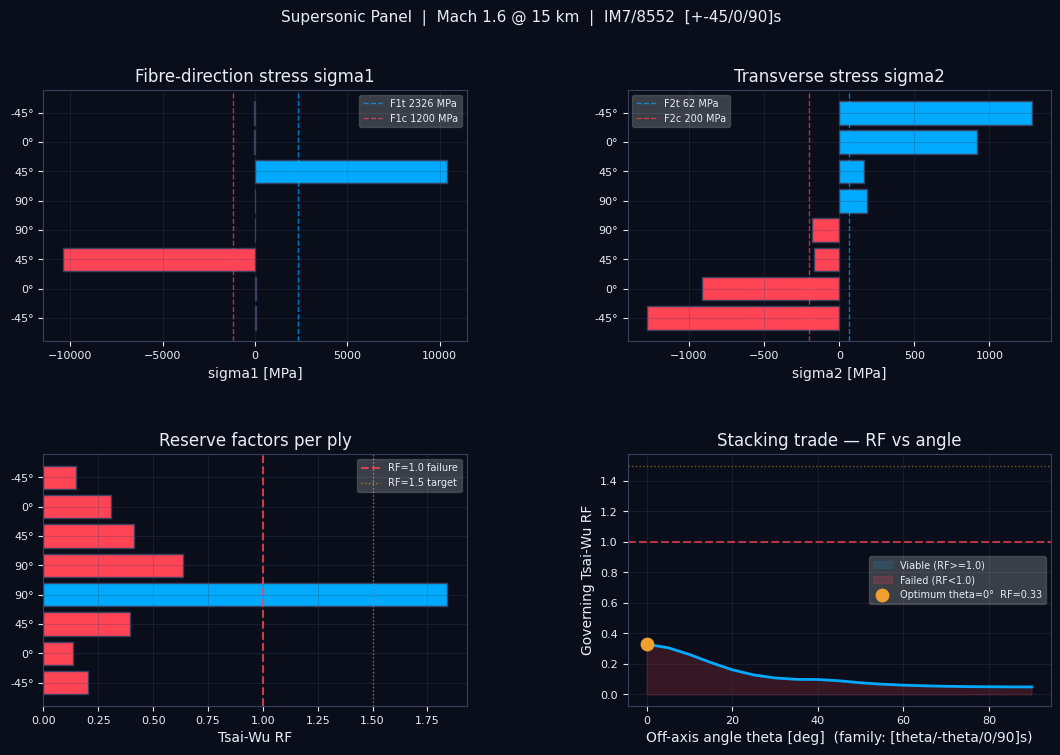

In [8]:
BG    = '#0a0e1a'
BLUE  = '#00aaff'
WHITE = '#e8edf5'
GOLD  = '#f0a030'
RED   = '#ff4455'
DIM   = '#3a4060'

def _style(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=WHITE, labelsize=8)
    ax.xaxis.label.set_color(WHITE)
    ax.yaxis.label.set_color(WHITE)
    ax.title.set_color(WHITE)
    for sp in ax.spines.values():
        sp.set_edgecolor(DIM)
    ax.grid(color=DIM, linewidth=0.4, alpha=0.5)

fig, axes = plt.subplots(2, 2, figsize=(13, 8), facecolor=BG)
fig.suptitle(f'Supersonic Panel  |  Mach {MACH} @ {ALT_M/1e3:.0f} km  |  IM7/8552  [+-45/0/90]s',
             color=WHITE, fontsize=11)
fig.subplots_adjust(hspace=0.45, wspace=0.38)

# --- sigma1 ---
ax = axes[0, 0]
sig1 = [r['ply_stress_12'][k][0] / 1e6 for k in range(len(plies))]
ax.barh(range(len(plies)), sig1,
        color=[RED if s < 0 else BLUE for s in sig1], edgecolor=DIM)
ax.axvline( mat.F1t/1e6, color=BLUE, lw=1, ls='--', alpha=0.7, label=f'F1t {mat.F1t/1e6:.0f} MPa')
ax.axvline(-mat.F1c/1e6, color=RED,  lw=1, ls='--', alpha=0.7, label=f'F1c {mat.F1c/1e6:.0f} MPa')
ax.set_yticks(range(len(plies))); ax.set_yticklabels([f'{a}°' for a in angles], fontsize=7)
ax.set_xlabel('sigma1 [MPa]'); ax.set_title('Fibre-direction stress sigma1')
ax.legend(fontsize=7, framealpha=0.2, labelcolor=WHITE)
_style(ax)

# --- sigma2 ---
ax = axes[0, 1]
sig2 = [r['ply_stress_12'][k][1] / 1e6 for k in range(len(plies))]
ax.barh(range(len(plies)), sig2,
        color=[RED if s < 0 else BLUE for s in sig2], edgecolor=DIM)
ax.axvline( mat.F2t/1e6, color=BLUE, lw=1, ls='--', alpha=0.7, label=f'F2t {mat.F2t/1e6:.0f} MPa')
ax.axvline(-mat.F2c/1e6, color=RED,  lw=1, ls='--', alpha=0.7, label=f'F2c {mat.F2c/1e6:.0f} MPa')
ax.set_yticks(range(len(plies))); ax.set_yticklabels([f'{a}°' for a in angles], fontsize=7)
ax.set_xlabel('sigma2 [MPa]'); ax.set_title('Transverse stress sigma2')
ax.legend(fontsize=7, framealpha=0.2, labelcolor=WHITE)
_style(ax)

# --- Tsai-Wu RF ---
ax = axes[1, 0]
bar_colors = [RED if rf < 1.0 else (GOLD if rf < 1.5 else BLUE) for rf in rfs]
ax.barh(range(len(plies)), rfs, color=bar_colors, edgecolor=DIM)
ax.axvline(1.0, color=RED,  lw=1.5, ls='--', alpha=0.8, label='RF=1.0 failure')
ax.axvline(1.5, color=GOLD, lw=1.0, ls=':',  alpha=0.6, label='RF=1.5 target')
ax.set_yticks(range(len(plies))); ax.set_yticklabels([f'{a}°' for a in angles], fontsize=7)
ax.set_xlabel('Tsai-Wu RF'); ax.set_title('Reserve factors per ply')
ax.legend(fontsize=7, framealpha=0.2, labelcolor=WHITE)
_style(ax)

# --- Stacking trade ---
ax = axes[1, 1]
ax.plot(sweep_angles, governing_rf, color=BLUE, lw=2)
ax.fill_between(sweep_angles, 0, governing_rf, where=(governing_rf >= 1.0),
                alpha=0.12, color=BLUE, label='Viable (RF>=1.0)')
ax.fill_between(sweep_angles, 0, governing_rf, where=(governing_rf < 1.0),
                alpha=0.18, color=RED, label='Failed (RF<1.0)')
ax.axhline(1.0, color=RED,  lw=1.5, ls='--', alpha=0.7)
ax.axhline(1.5, color=GOLD, lw=1.0, ls=':',  alpha=0.5)
ax.scatter(sweep_angles[opt_idx], governing_rf[opt_idx], color=GOLD, s=80, zorder=5,
           label=f'Optimum theta={sweep_angles[opt_idx]}°  RF={governing_rf[opt_idx]:.2f}')
ax.set_xlabel('Off-axis angle theta [deg]  (family: [theta/-theta/0/90]s)')
ax.set_ylabel('Governing Tsai-Wu RF')
ax.set_title('Stacking trade — RF vs angle')
ax.legend(fontsize=7, framealpha=0.2, labelcolor=WHITE)
_style(ax)

plt.show()

---
## 8. Key Takeaways

1. **Ackeret loads** scale with `alpha / sqrt(M^2 - 1)`, so supersonic dynamic pressure drives Nyy (chordwise compression) very hard on the upper skin.
2. **CLT** is pure linear algebra once you have the Q-bar matrices — the `Laminate.response()` call handles everything.
3. **Tsai-Wu RF** accounts for interaction between sigma1, sigma2, and tau12 via the F12 coupling term. Purely uniaxial failure criteria (max-stress, Tsai-Hill) can be non-conservative under biaxial loading.
4. **The QI layup is not optimal** for this load case. The stacking trade shows a better RF is available at the angle where ±theta plies carry shear most efficiently while 0° plies handle the dominant Nxx.
5. Structural margins depend on both the laminate **and** the load case — always check the governing ply and loading direction.